In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [27]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [4]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(42000, 785)

In [7]:
import matplotlib.pyplot as plt

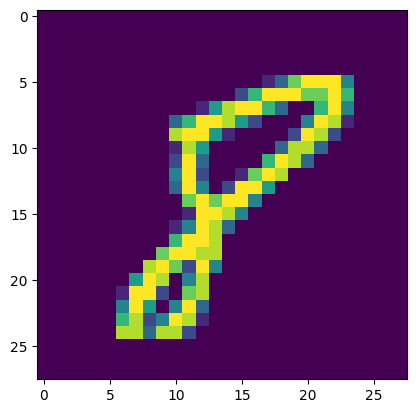

In [8]:
plt.imshow(df.iloc[18306, 1:].values.reshape(28, 28))

In [28]:
X = df.iloc[:, 1:]
Y = df.iloc[:, 0]

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [11]:
x_train.shape

(33600, 784)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [14]:
import time
start = time.time()
y_pred = knn.predict(x_test)
print(time.time() - start)

11.188678979873657


In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9648809523809524

# **Applying PCA** 

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [30]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [31]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=100)

In [32]:
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [33]:
x_train.shape

(33600, 784)

In [34]:
x_train_trf.shape

(33600, 100)

In [35]:
knn = KNeighborsClassifier()

In [36]:
knn.fit(x_train_trf, y_train)

KNeighborsClassifier()

In [37]:
y_pred = knn.predict(x_test_trf)

In [38]:
accuracy_score(y_test, y_pred)

0.9544047619047619

## for 784 feautes accuracy -> 96%
## for 100 features accuracy -> 95%

In [44]:
for i in range(1, 784):
    pca = PCA(n_components=i)
    x_train_trf = pca.fit_transform(x_train)
    x_test_trf = pca.transform(x_test)
    knn = KNeighborsClassifier()
    knn.fit(x_train_trf, y_train)
    y_pred = knn.predict(x_test_trf)

    print("Number of components:",i, ",", "accuracy:", accuracy_score(y_test, y_pred))

Number of components: 1 , accuracy: 0.2580952380952381
Number of components: 2 , accuracy: 0.3236904761904762
Number of components: 3 , accuracy: 0.5104761904761905
Number of components: 4 , accuracy: 0.6663095238095238
Number of components: 5 , accuracy: 0.7378571428571429
Number of components: 6 , accuracy: 0.8227380952380953
Number of components: 7 , accuracy: 0.8436904761904762
Number of components: 8 , accuracy: 0.8721428571428571
Number of components: 9 , accuracy: 0.886547619047619
Number of components: 10 , accuracy: 0.9055952380952381
Number of components: 11 , accuracy: 0.9116666666666666
Number of components: 12 , accuracy: 0.9184523809523809
Number of components: 13 , accuracy: 0.9276190476190476
Number of components: 14 , accuracy: 0.9351190476190476
Number of components: 15 , accuracy: 0.9384523809523809
Number of components: 16 , accuracy: 0.9379761904761905
Number of components: 17 , accuracy: 0.9407142857142857
Number of components: 18 , accuracy: 0.94
Number of compon

KeyboardInterrupt: 

In [45]:
#Transform to a 2D coordinate system
pca = PCA(n_components=2)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [46]:
x_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

In [52]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=x_train_trf[:, 0],
                 y=x_train_trf[:, 1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [54]:
# transforming 3D
pca = PCA(n_components=3)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [56]:

y_train_trf = y_train.astype(str)
fig = px.scatter_3d(x=x_train_trf[:, 0],
                 y=x_train_trf[:, 1],
                 z=x_train_trf[:, 2],
                 color=y_train_trf)

                
fig.update_layout(margin=dict(l = 20, r = 20, t = 20, b = 20))
fig.show()

In [57]:
# Eigen Values
pca.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

In [58]:
# Eigen Vectors
pca.components_.shape

(3, 784)

In [62]:
# gives variance percentage in each eigen values

pca.explained_variance_ratio_ * 100

# lamda1 - 5%, lamda2 - 4%, lamda3 - 3.8%
# these values explains a total of 12.8% variance in the data

array([5.78519225, 4.14926968, 3.80423901])

In [63]:
pca = PCA(n_components=None)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [64]:
pca.explained_variance_.shape

(784,)

In [65]:
pca.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(784, 784))

In [66]:
pca.explained_variance_ratio_ * 100

array([5.78519225e+00, 4.14926968e+00, 3.80423901e+00, 2.96626277e+00,
       2.58156168e+00, 2.25498018e+00, 1.97306802e+00, 1.77527998e+00,
       1.56865066e+00, 1.43606328e+00, 1.37025484e+00, 1.22725500e+00,
       1.14691200e+00, 1.12302739e+00, 1.05852885e+00, 1.01993106e+00,
       9.57676152e-01, 9.42708817e-01, 9.12489429e-01, 8.90170190e-01,
       8.39940495e-01, 8.20063196e-01, 7.85303229e-01, 7.56739707e-01,
       7.37261022e-01, 7.01884653e-01, 6.97919728e-01, 6.71104483e-01,
       6.39845030e-01, 6.30337291e-01, 6.15350848e-01, 6.02388659e-01,
       5.83673972e-01, 5.78547759e-01, 5.72333148e-01, 5.46399774e-01,
       5.43207369e-01, 5.28172755e-01, 5.13381744e-01, 4.94015474e-01,
       4.87671103e-01, 4.81978768e-01, 4.68204430e-01, 4.59342487e-01,
       4.57660834e-01, 4.49219022e-01, 4.44682221e-01, 4.41540749e-01,
       4.35111936e-01, 4.32032928e-01, 4.21808870e-01, 4.18243127e-01,
       4.07994349e-01, 4.02004913e-01, 3.98335855e-01, 3.94598812e-01,
      

In [69]:
np.cumsum(pca.explained_variance_ratio_ * 100)

array([  5.78519225,   9.93446193,  13.73870094,  16.70496371,
        19.2865254 ,  21.54150558,  23.5145736 ,  25.28985357,
        26.85850424,  28.29456752,  29.66482235,  30.89207736,
        32.03898935,  33.16201674,  34.22054559,  35.24047664,
        36.1981528 ,  37.14086161,  38.05335104,  38.94352123,
        39.78346173,  40.60352492,  41.38882815,  42.14556786,
        42.88282888,  43.58471353,  44.28263326,  44.95373775,
        45.59358278,  46.22392007,  46.83927092,  47.44165957,
        48.02533355,  48.6038813 ,  49.17621445,  49.72261423,
        50.2658216 ,  50.79399435,  51.30737609,  51.80139157,
        52.28906267,  52.77104144,  53.23924587,  53.69858836,
        54.15624919,  54.60546821,  55.05015043,  55.49169118,
        55.92680312,  56.35883605,  56.78064492,  57.19888804,
        57.60688239,  58.00888731,  58.40722316,  58.80182197,
        59.18869358,  59.57188877,  59.94844139,  60.32263485,
        60.68748701,  61.04828955,  61.402176  ,  61.75

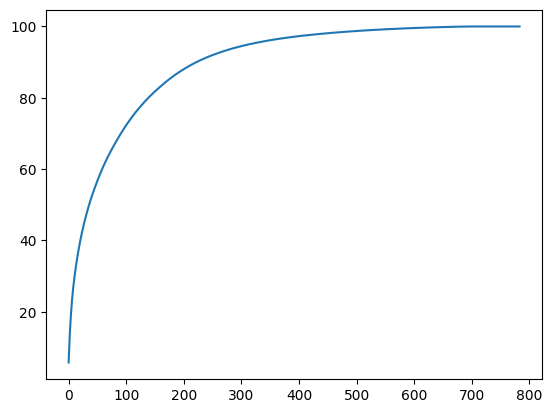

In [70]:
plt.plot(np.cumsum(pca.explained_variance_ratio_ * 100))